In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI 
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings # type: ignore
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START , END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition



c:\Users\dell\Desktop\Langgraph-learning\agent\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.7) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\dell\Desktop\Langgraph-learning\agent\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.9)

In [3]:
loader = PyPDFLoader("intro-to-ml.pdf")
docs = loader.load()
len(docs)

392

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)
len(chunks)

973

In [5]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 238.60it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [7]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [8]:
vector_store

In [9]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [10]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [11]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [12]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [13]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}


In [14]:
tool_node = ToolNode(tools)

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

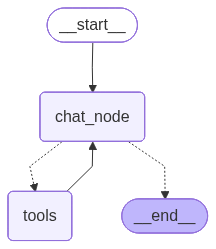

In [15]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [18]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain decision trees in simple terms with an example. "
                )
            )
        ]
    }
)

In [19]:
print(result['messages'][-1].content)

Imagine you're trying to categorize different animals. A decision tree is like a series of "if/else" questions that help you figure out what an animal is, leading you to the correct answer as quickly as possible.

Here's a simple example:

Let's say you want to classify animals into Hawks, Penguins, Dolphins, and Bears. You could use a decision tree with questions like:

*   **Does it have feathers?**
    *   If **yes**, then ask: **Can it fly?**
        *   If **yes**, it's a **Hawk**.
        *   If **no**, it's a **Penguin**.
    *   If **no**, then ask: **Does it have fins?**
        *   If **yes**, it's a **Dolphin**.
        *   If **no**, it's a **Bear**.

In this example:

*   Each "node" in the tree is a question (e.g., "Does it have feathers?").
*   The "edges" are the possible answers (yes/no).
*   The "leaves" (terminal nodes) are the final answers (e.g., Hawk, Penguin).

In machine learning, instead of building these trees by hand, a computer algorithm learns these "if/els